In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("sales_cleaned.csv")
print(df.head())

         Date Product  Sales  Quantity Region
0  01-01-2024       A    200         2  North
1  02-01-2024       B    150         1  South
2  03-01-2024       C    300         3   East
3  04-01-2024       A    250         2   West
4  05-01-2024       B    180         1  North


0


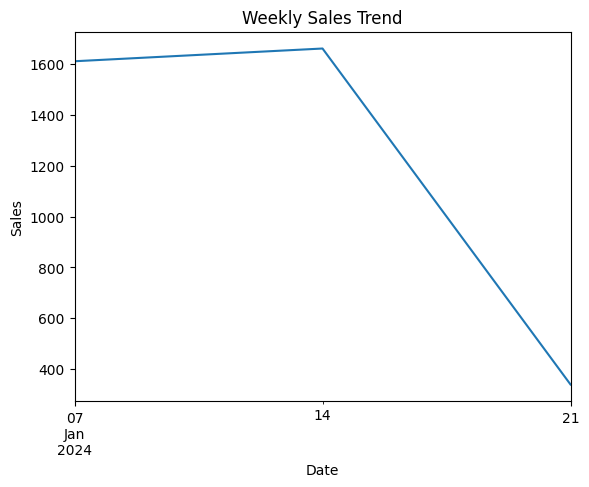

In [3]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# check if any invalid dates
print(df['Date'].isnull().sum())

df.set_index('Date', inplace=True)

weekly_sales = df['Sales'].resample('W').sum()

weekly_sales.plot(title="Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

In [4]:
pivot = df.pivot_table(values='Sales', index='Product', aggfunc=['sum', 'mean'])
print(pivot)

          sum   mean
        Sales  Sales
Product             
A        1160  232.0
B         850  170.0
C        1600  320.0


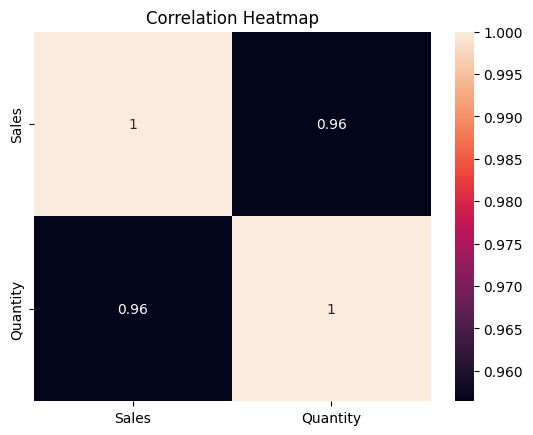

In [5]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

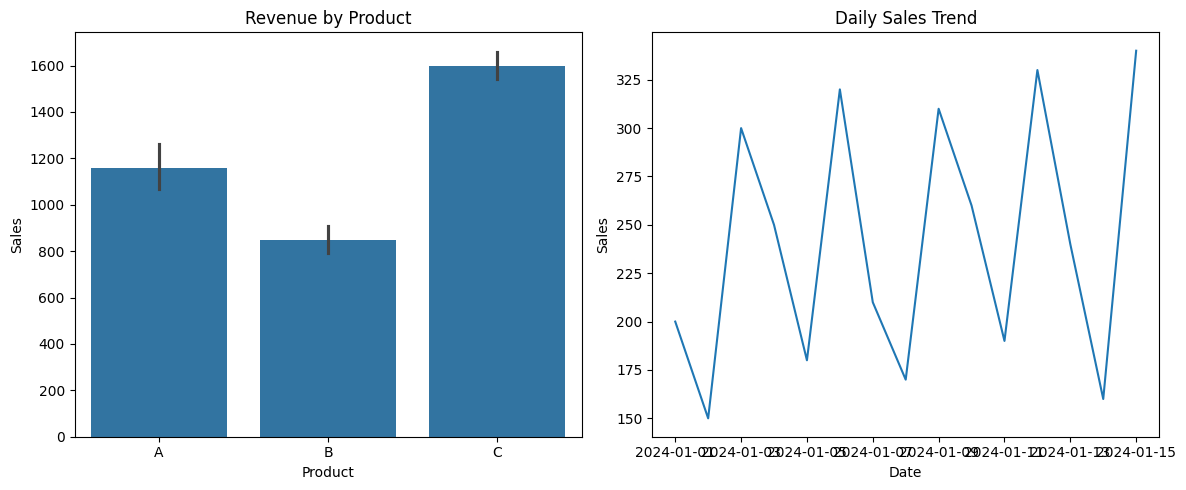

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Bar Chart
sns.barplot(ax=axes[0], x='Product', y='Sales', data=df.reset_index(), estimator=sum)
axes[0].set_title("Revenue by Product")

# Line Chart
daily_sales = df.groupby('Date')['Sales'].sum()
sns.lineplot(ax=axes[1], data=daily_sales)
axes[1].set_title("Daily Sales Trend")

plt.tight_layout()
plt.show()

In [7]:
df['Projected_Sales'] = df['Sales'] * 1.15
print(df.head())

           Product  Sales  Quantity Region  Projected_Sales
Date                                                       
2024-01-01       A    200         2  North            230.0
2024-01-02       B    150         1  South            172.5
2024-01-03       C    300         3   East            345.0
2024-01-04       A    250         2   West            287.5
2024-01-05       B    180         1  North            207.0


In [8]:
summary = df.groupby('Product').agg({
    'Sales': 'sum',
    'Quantity': 'count'
})

print(summary)

         Sales  Quantity
Product                 
A         1160         5
B          850         5
C         1600         5


In [9]:
top_products = df.groupby('Product')['Sales'].sum().nlargest(2)

total = df['Sales'].sum()
percent = (top_products.sum() / total) * 100

print("Top products contribution:", percent)

Top products contribution: 76.45429362880887


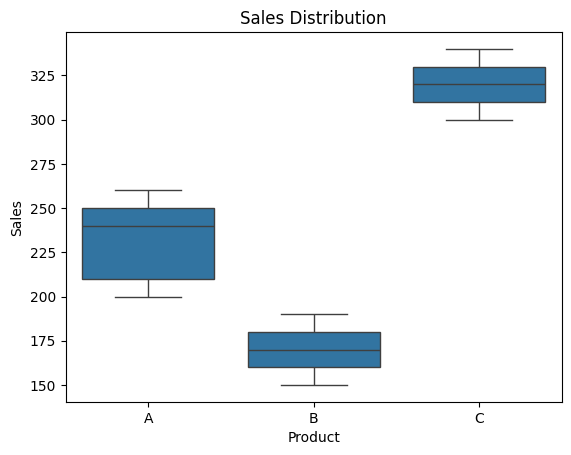

In [10]:
sns.boxplot(x='Product', y='Sales', data=df)
plt.title("Sales Distribution")
plt.show()

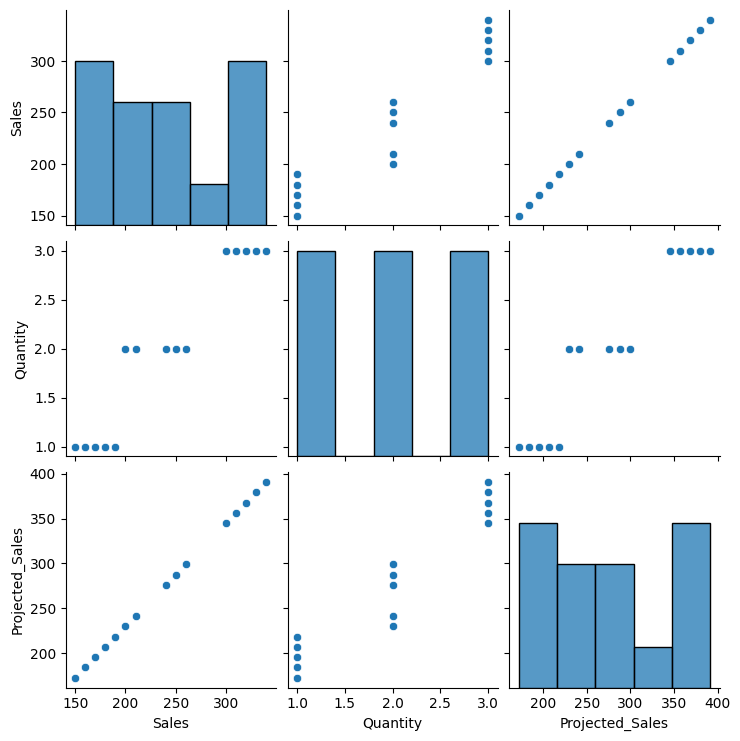

In [11]:
sns.pairplot(df)
plt.show()

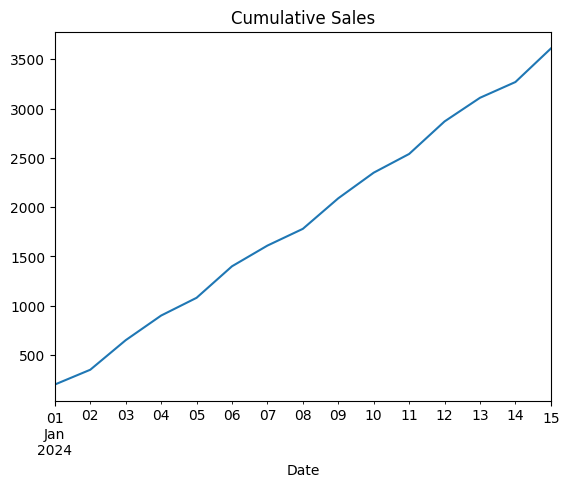

In [12]:
df['Sales'].cumsum().plot(title="Cumulative Sales")
plt.show()